# Backtesting

As a result of my exploration in `stock-selection.ipynb` and `clustering.ipynb`, I have come to a final selection of stocks that are based on the real estate industry and REIT-Residential sector from Yahoo Finance. Using these stocks I conducted a manual backtest.

## 1. Download data

In [1]:
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

FINAL_TICKERS = ["AMH", "AVB", "CPT", "ELS", "EQR", "IRT", "MAA", "SUI", "UDR", "UMH"]

end_date = "2026-06-30"
start_date = (pd.to_datetime(end_date) - pd.DateOffset(365*12)).strftime('%Y-%m-%d')
df = yf.download(FINAL_TICKERS, start=start_date, end=end_date, auto_adjust=True)['Close']


df = df.dropna(axis=1)

print('df size: ', df.shape)

[*********************100%***********************]  10 of 10 completed

df size:  (3014, 10)


## 2. Implement Strategy

For my first strategy, we will implement single cluster mean reversion. This strategy was taken from [151 Trading Strategies](https://ssrn.com/abstract=3247865) page 46-47. The functions have all been implemented in `backtest.py` as I need to reuse them later in `meta-labelling.ipynb`

In [2]:
from backtest import (
    backtest_positions,
    build_mean_reversion_positions,
    prepare_weekly_data,
    print_stats,
    run_benchmark,
    run_backtest,
)

I = 10_000


## 3. Backtesting

### 3.1 Full backtest

Running the strategy on ALL of the downloaded data (~12 years) with no transaction cost

--- Strategy ---
Total return: 178.36%
Sharpe ratio: 1.28
Max drawdown: -8.56%
--- Benchmark ---
Total return: 190.85%
Sharpe ratio: 0.52
Max drawdown: -39.51%


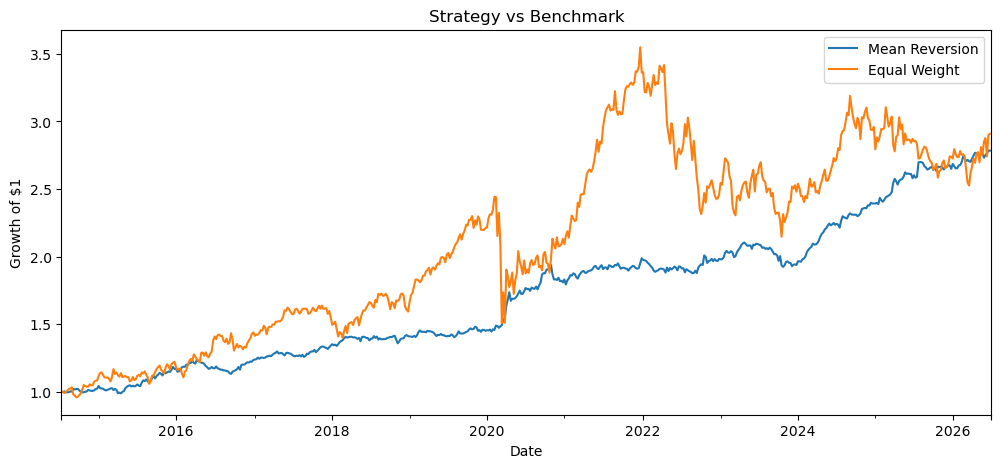

In [3]:
end = df.index.max()
start = df.index.min()

strategy = run_backtest(df, start_date=start, end_date=end, cost_bps=0)
benchmark = run_benchmark(df, start_date=start, end_date=end)

print("--- Strategy ---")
print_stats(strategy["stats"])

print("--- Benchmark ---")
print_stats(benchmark["stats"])


equity = strategy["equity"]
cluster_equity = benchmark["equity"]

plt.figure(figsize=(12, 5))
(equity / equity.iloc[0]).plot(label="Mean Reversion")
(cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
plt.legend()
plt.ylabel("Growth of $1")
plt.title("Strategy vs Benchmark")
plt.show()

### 3.2 Backtest on multiple time periods

To ensure that the results of the algorithm are consistent during different time periods, I tested the strategy on four 3 year periods throughout the 12 years of data.

---- 2014-07-03 00:00:00 to 2017-07-03 00:00:00 ----
--- Strategy ---
Total return: 27.99%
Sharpe ratio: 1.31
Max drawdown: -8.33%
--- Benchmark ---
Total return: 60.18%
Sharpe ratio: 1.15
Max drawdown: -9.44%


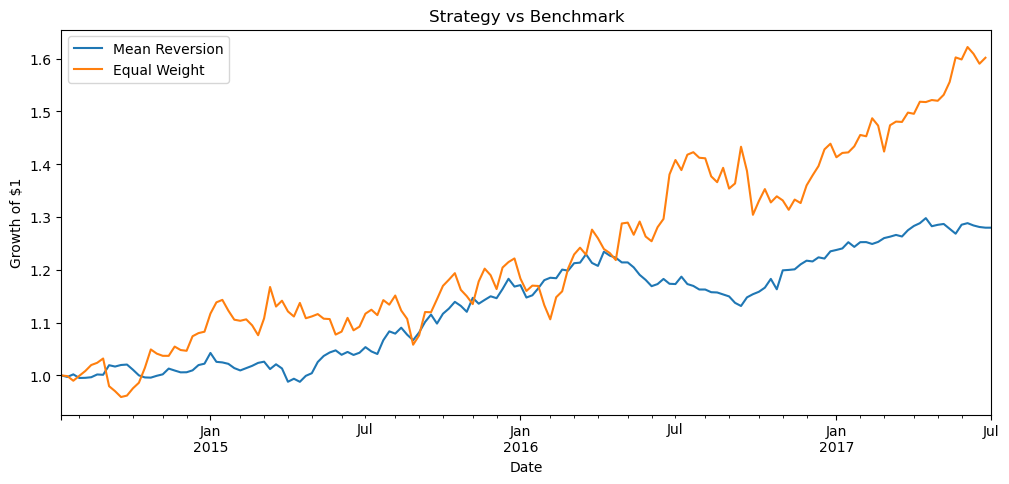

---- 2017-07-03 00:00:00 to 2020-07-03 00:00:00 ----
--- Strategy ---
Total return: 38.09%
Sharpe ratio: 1.47
Max drawdown: -3.92%
--- Benchmark ---
Total return: 22.63%
Sharpe ratio: 0.40
Max drawdown: -38.24%


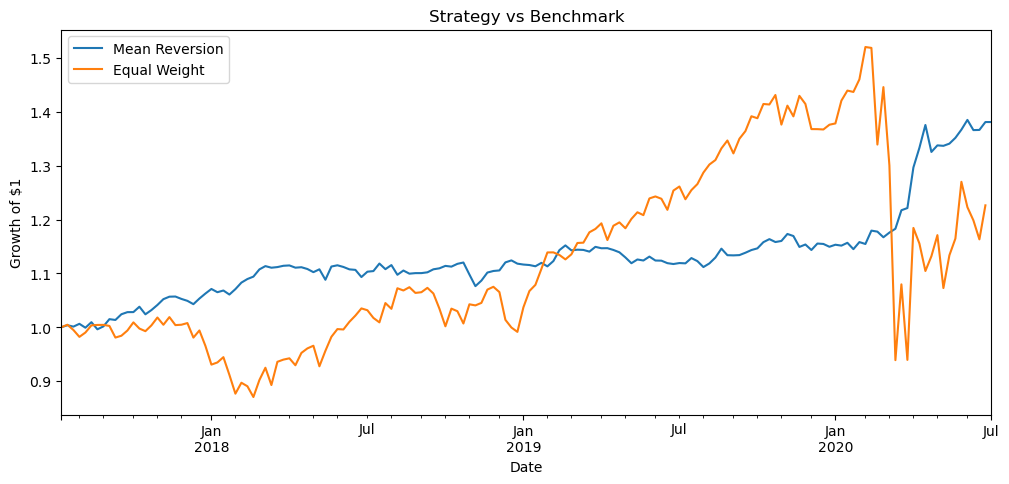

---- 2020-07-03 00:00:00 to 2023-07-03 00:00:00 ----
--- Strategy ---
Total return: 18.66%
Sharpe ratio: 0.84
Max drawdown: -7.49%
--- Benchmark ---
Total return: 40.04%
Sharpe ratio: 0.61
Max drawdown: -35.04%


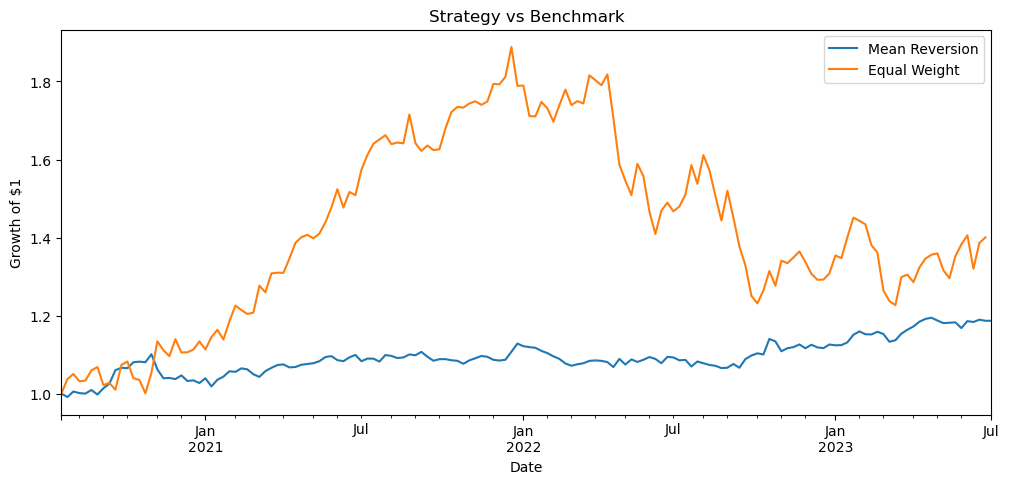

---- 2023-07-03 00:00:00 to 2026-06-29 00:00:00 ----
--- Strategy ---
Total return: 33.63%
Sharpe ratio: 1.59
Max drawdown: -7.65%
--- Benchmark ---
Total return: 7.81%
Sharpe ratio: 0.25
Max drawdown: -20.81%


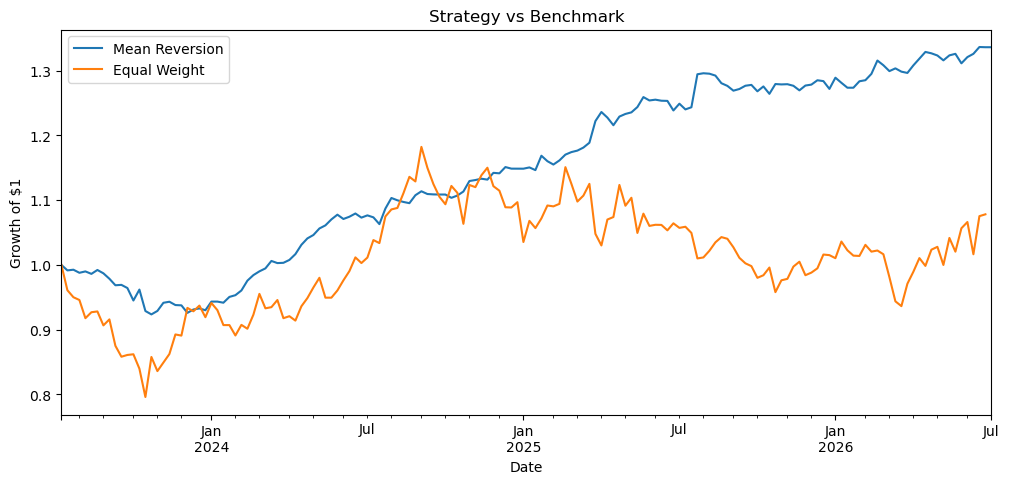

In [4]:
periods = [
    (start, start + pd.DateOffset(years=3)),
    (start + pd.DateOffset(years=3), start + pd.DateOffset(years=6)),
    (start + pd.DateOffset(years=6), start + pd.DateOffset(years=9)),
    (start + pd.DateOffset(years=9), end),
]

for s, e in periods:
    print(f"---- {s} to {e} ----")
    strategy = run_backtest(df, start_date=s, end_date=e, cost_bps=0)
    benchmark = run_benchmark(df, start_date=s, end_date=e)

    print("--- Strategy ---")
    print_stats(strategy["stats"])

    print("--- Benchmark ---")
    print_stats(benchmark["stats"])


    equity = strategy["equity"]
    cluster_equity = benchmark["equity"]

    plt.figure(figsize=(12, 5))
    (equity / equity.iloc[0]).plot(label="Mean Reversion")
    (cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
    plt.legend()
    plt.ylabel("Growth of $1")
    plt.title("Strategy vs Benchmark")
    plt.show()


#### Conclusion

The algorithm performed well on three periods out of the 4, with the 2014-2017, 2017-2020 and 2023-2026 time periods having an average Sharpe Ratio of ~1.45. However, during the 2020-2023 period the Sharpe Ratio dropped below 1 to around 0.8. This suggests the strategy is generally robust across several regimes, but may be less effective during economic uncertainty.

### 3.3 Leave-one-out backtest
This backtest tests the stock cluster for overreliance on one specific stock. For each stock in the cluster, we remove it and run the algorithm on the remaining stocks. If removing any of the one stocks from the cluster significantly reduces the algorithm's result, then the strategy likely depends on that one stock. These were tested on the last three years of data.

--- Strategy ---
Total return: 173.76%
Sharpe ratio: 1.19
Max drawdown: -10.12%
--- Benchmark ---
Total return: 195.48%
Sharpe ratio: 0.52
Max drawdown: -41.04%


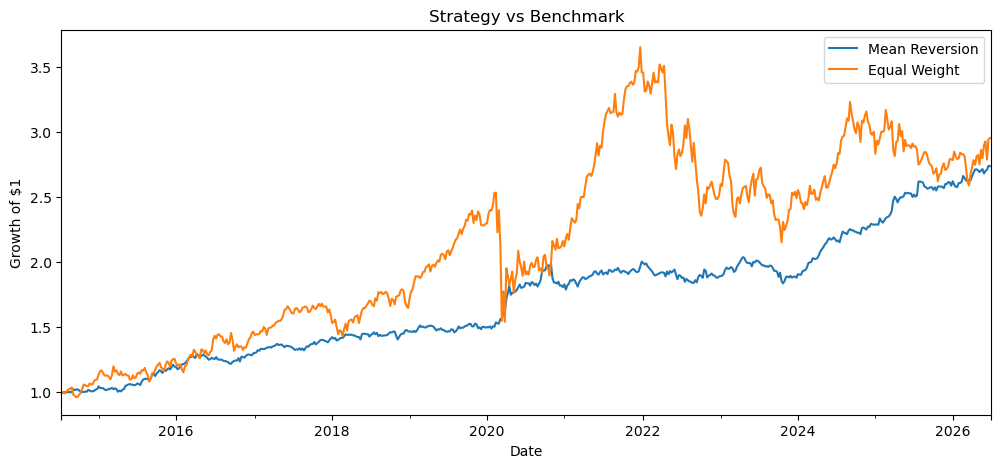

--- Strategy ---
Total return: 181.86%
Sharpe ratio: 1.26
Max drawdown: -9.75%
--- Benchmark ---
Total return: 202.47%
Sharpe ratio: 0.53
Max drawdown: -40.40%


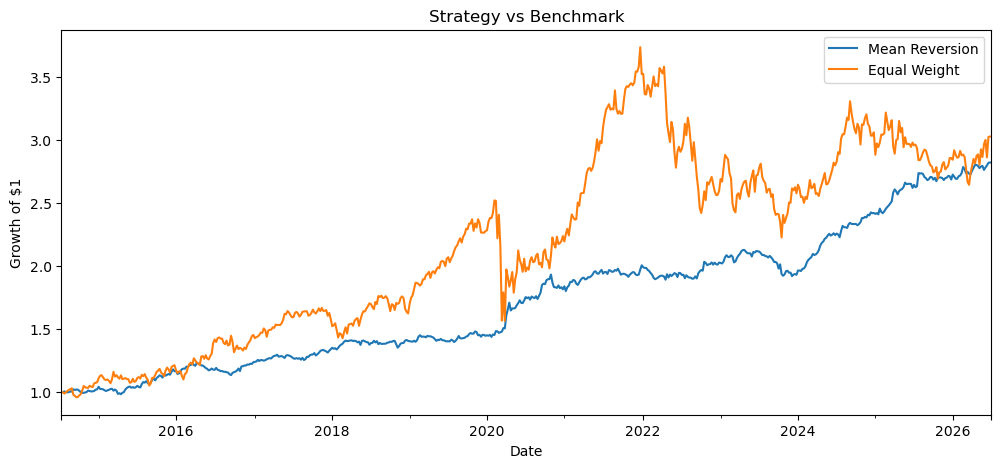

--- Strategy ---
Total return: 184.98%
Sharpe ratio: 1.24
Max drawdown: -9.29%
--- Benchmark ---
Total return: 193.69%
Sharpe ratio: 0.52
Max drawdown: -38.25%


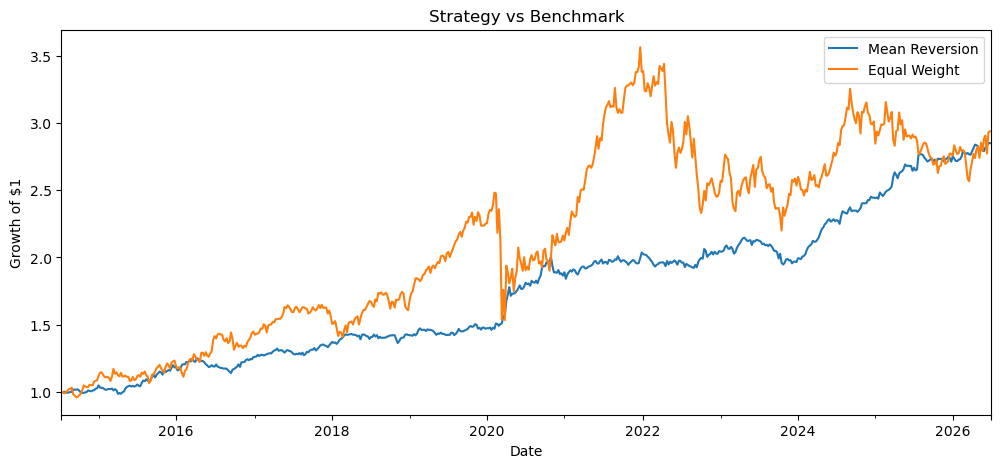

--- Strategy ---
Total return: 169.98%
Sharpe ratio: 1.21
Max drawdown: -10.68%
--- Benchmark ---
Total return: 178.35%
Sharpe ratio: 0.50
Max drawdown: -41.23%


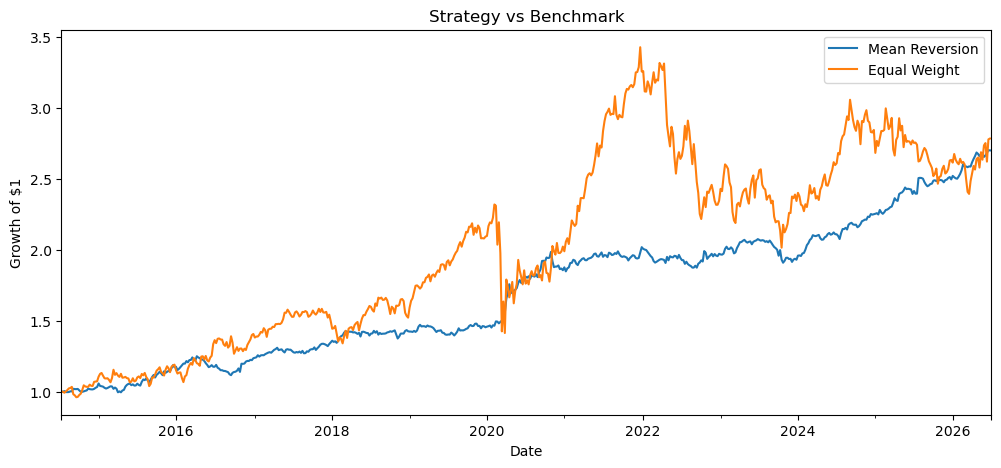

--- Strategy ---
Total return: 214.27%
Sharpe ratio: 1.40
Max drawdown: -9.17%
--- Benchmark ---
Total return: 202.78%
Sharpe ratio: 0.53
Max drawdown: -39.97%


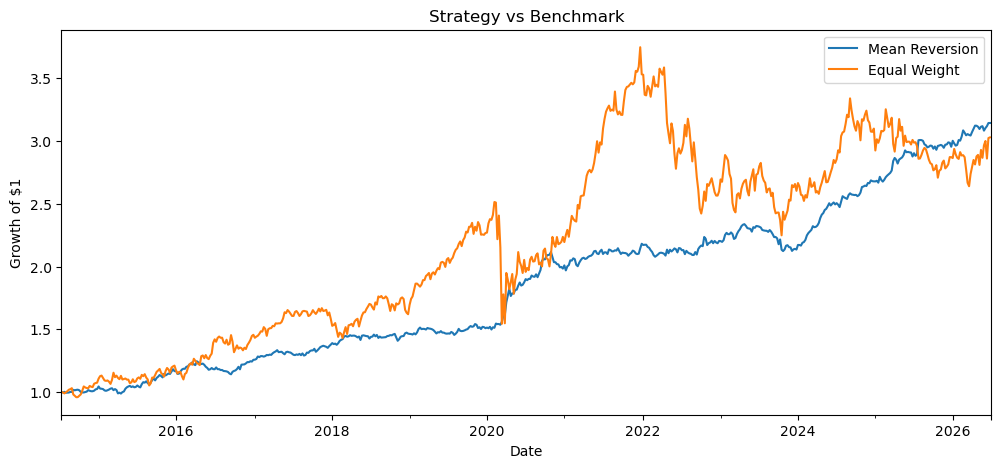

--- Strategy ---
Total return: 122.29%
Sharpe ratio: 1.00
Max drawdown: -8.60%
--- Benchmark ---
Total return: 180.04%
Sharpe ratio: 0.51
Max drawdown: -38.41%


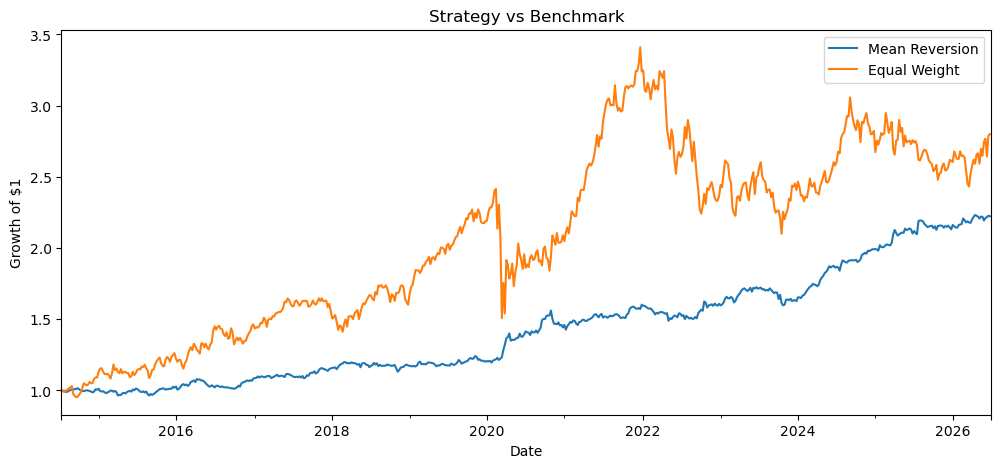

--- Strategy ---
Total return: 184.01%
Sharpe ratio: 1.26
Max drawdown: -9.45%
--- Benchmark ---
Total return: 189.06%
Sharpe ratio: 0.52
Max drawdown: -38.86%


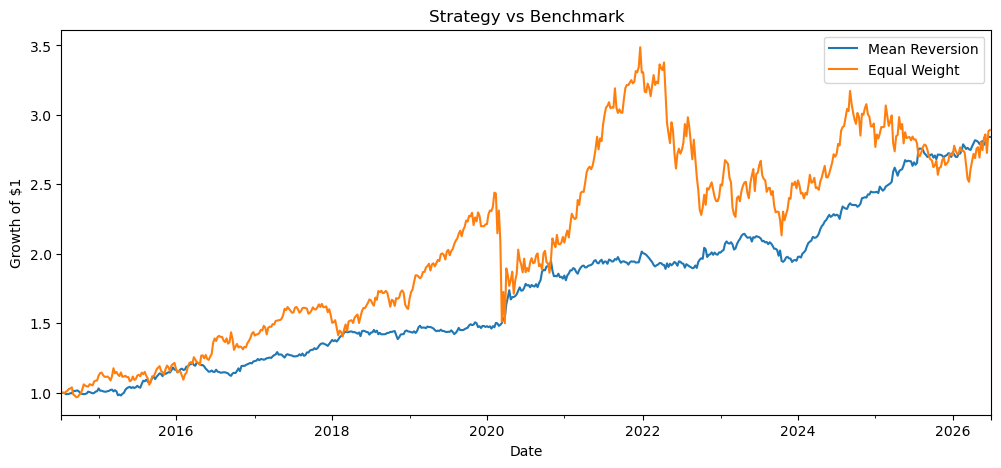

--- Strategy ---
Total return: 164.33%
Sharpe ratio: 1.19
Max drawdown: -10.42%
--- Benchmark ---
Total return: 181.57%
Sharpe ratio: 0.50
Max drawdown: -38.92%


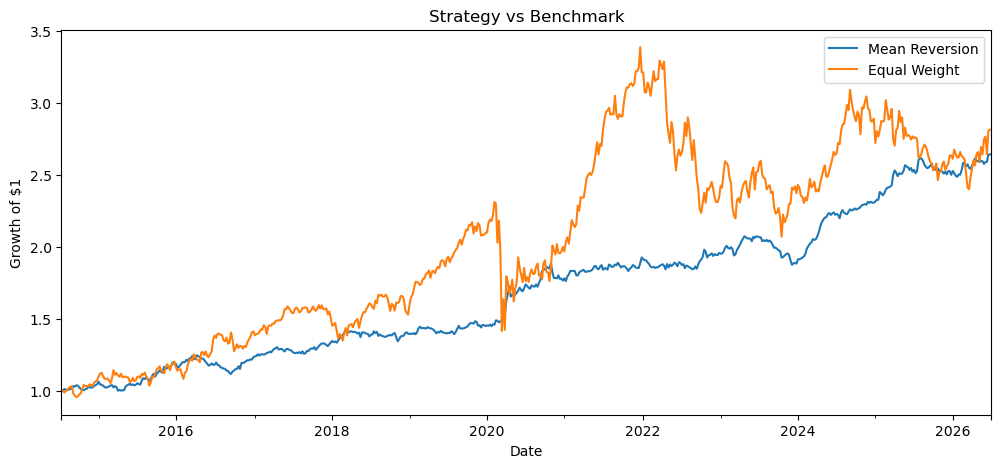

--- Strategy ---
Total return: 187.52%
Sharpe ratio: 1.29
Max drawdown: -8.89%
--- Benchmark ---
Total return: 199.32%
Sharpe ratio: 0.53
Max drawdown: -39.11%


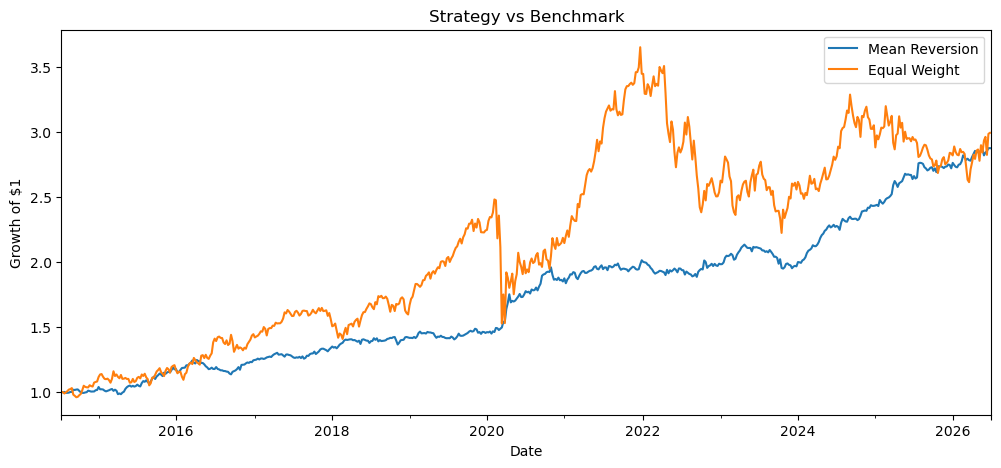

--- Strategy ---
Total return: 134.62%
Sharpe ratio: 1.06
Max drawdown: -9.20%
--- Benchmark ---
Total return: 183.80%
Sharpe ratio: 0.50
Max drawdown: -38.87%


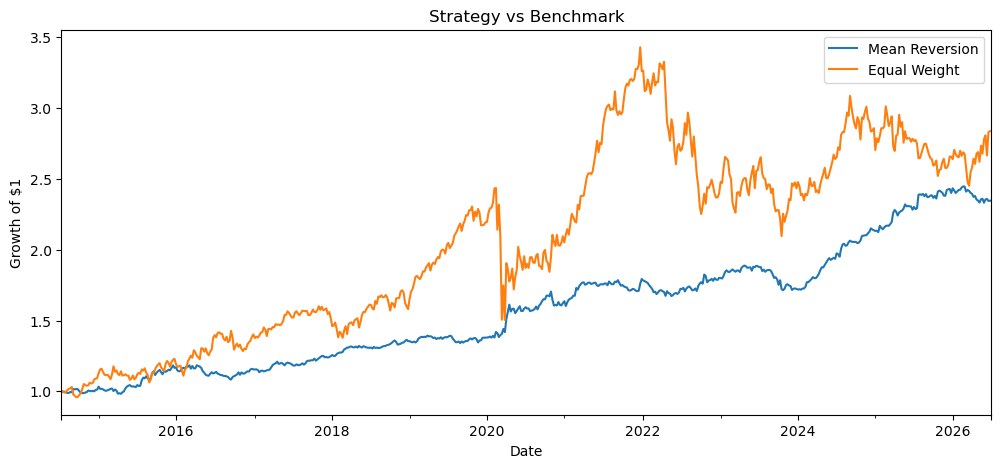

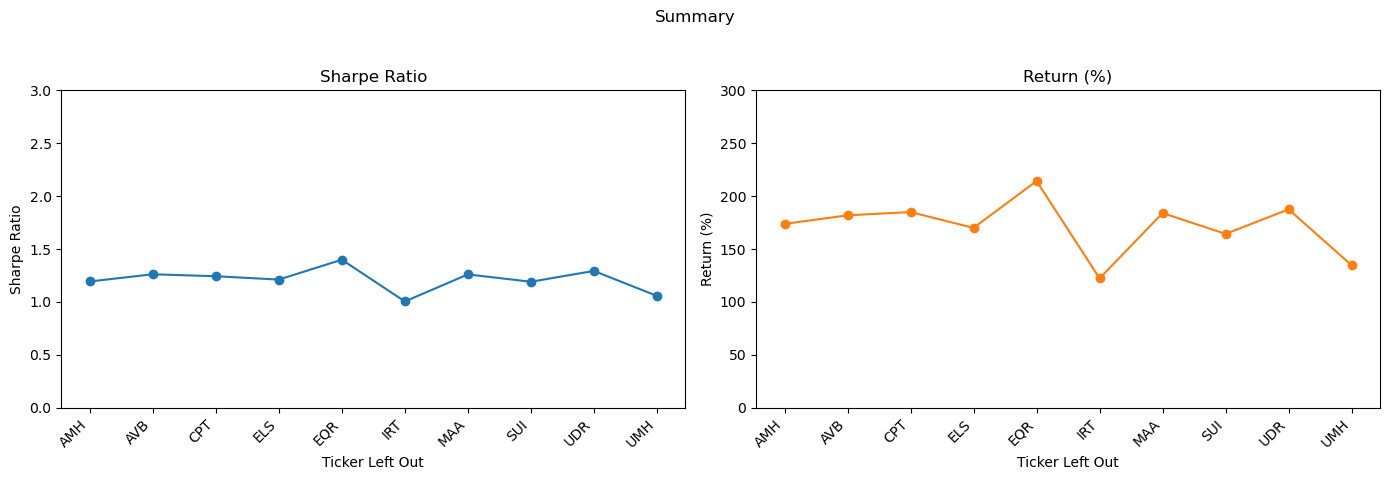

In [5]:
end = df.index.max()
start = end - pd.DateOffset(years=12)

sharpe_ratios = []
returns = []

for i in range(len(FINAL_TICKERS)):
    ticker = FINAL_TICKERS[i]
    df_no_ticker = df.drop(columns=[ticker])
    strategy = run_backtest(df_no_ticker, start_date=start, end_date=end, cost_bps=0)
    benchmark = run_benchmark(df_no_ticker, start_date=start, end_date=end)

    sharpe_ratios.append(strategy["stats"]["sharpe"])
    returns.append(strategy["stats"]["total_return_pct"])

    print("--- Strategy ---")
    print_stats(strategy["stats"])

    print("--- Benchmark ---")
    print_stats(benchmark["stats"])


    equity = strategy["equity"]
    cluster_equity = benchmark["equity"]

    plt.figure(figsize=(12, 5))
    (equity / equity.iloc[0]).plot(label="Mean Reversion")
    (cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
    plt.legend()
    plt.ylabel("Growth of $1")
    plt.title("Strategy vs Benchmark")
    plt.show()


# Plot the Sharpe Ratio and the Return
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Summary")

leaveout_labels = FINAL_TICKERS

axs[0].plot(leaveout_labels, sharpe_ratios, marker='o', linestyle='-')
axs[0].set_title("Sharpe Ratio")
axs[0].set_xlabel("Ticker Left Out")
axs[0].set_ylabel("Sharpe Ratio")
axs[0].set_ylim(bottom=0, top=3)
axs[0].set_xticks(range(len(leaveout_labels)))
axs[0].set_xticklabels(leaveout_labels, rotation=45, ha='right')

axs[1].plot(leaveout_labels, returns, marker='o', color='tab:orange', linestyle='-')
axs[1].set_title("Return (%)")
axs[1].set_xlabel("Ticker Left Out")
axs[1].set_ylabel("Return (%)")
axs[1].set_ylim(bottom=0, top=300)
axs[1].set_xticks(range(len(leaveout_labels)))
axs[1].set_xticklabels(leaveout_labels, rotation=45, ha='right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Conclusion

From the results it is clear that the strategy doesn't rely on any one stock in particular, as no matter which stock was removed, the strategy maintained a Sharpe Ratio of around 1.0-1.5, and a return of around 150-200%. 

It is worth noting that the removal of EQR improved the Sharpe Ratio and Return, whereas the removal of IRT decreased both the return and Sharpe Ratio, which could mean that IRT is one of the more important stocks in the cluster, whereas EQR is a stock that worses the performance of the cluster on average.

### 3.4 Backtest with transaction cost
My strategy has to rebalance every single week, therefore the transaction costs will add up. In order to find out how much the various transaction costs will hurt the strategy, I will test out the values 0.05%, 0.10% and 0.2%.

--- Strategy ---
Total return: 41.93%
Sharpe ratio: 0.67
Max drawdown: -9.71%
--- Benchmark ---
Total return: 176.48%
Sharpe ratio: 0.67
Max drawdown: -38.24%


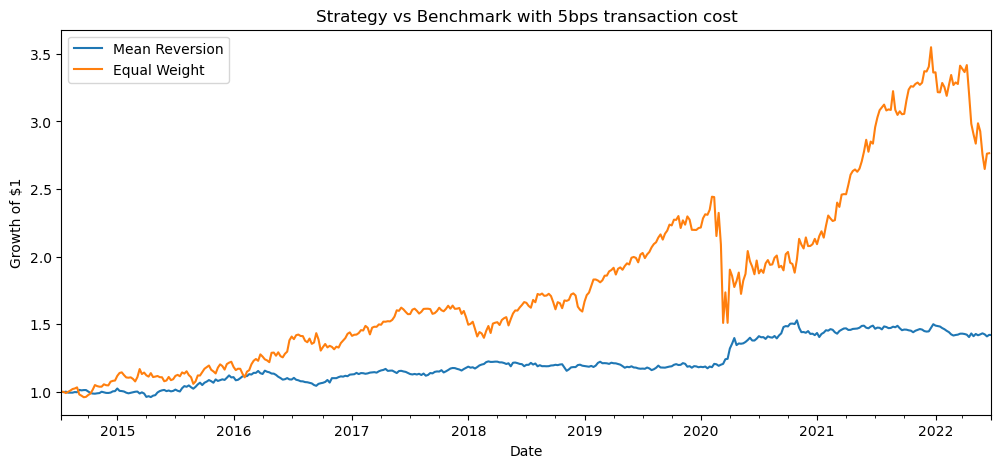

--- Strategy ---
Total return: 5.19%
Sharpe ratio: 0.15
Max drawdown: -13.15%
--- Benchmark ---
Total return: 176.48%
Sharpe ratio: 0.67
Max drawdown: -38.24%


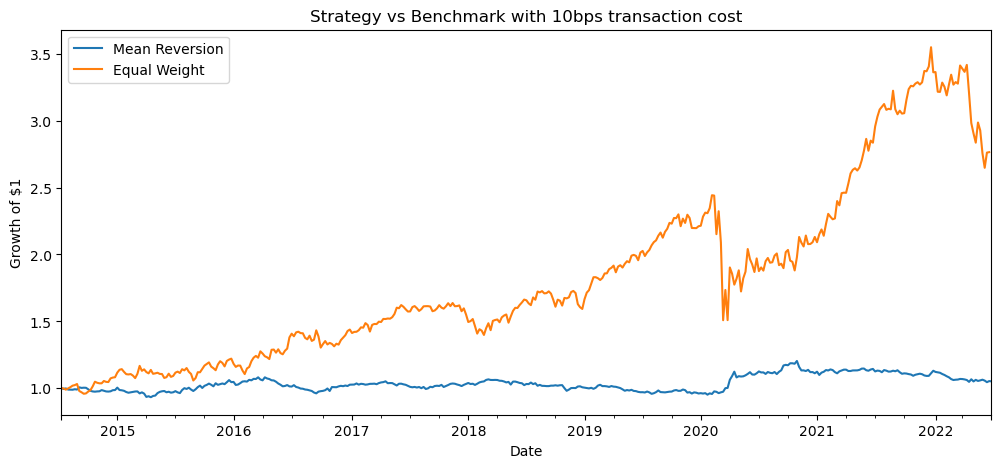

--- Strategy ---
Total return: -42.26%
Sharpe ratio: -0.89
Max drawdown: -42.44%
--- Benchmark ---
Total return: 176.48%
Sharpe ratio: 0.67
Max drawdown: -38.24%


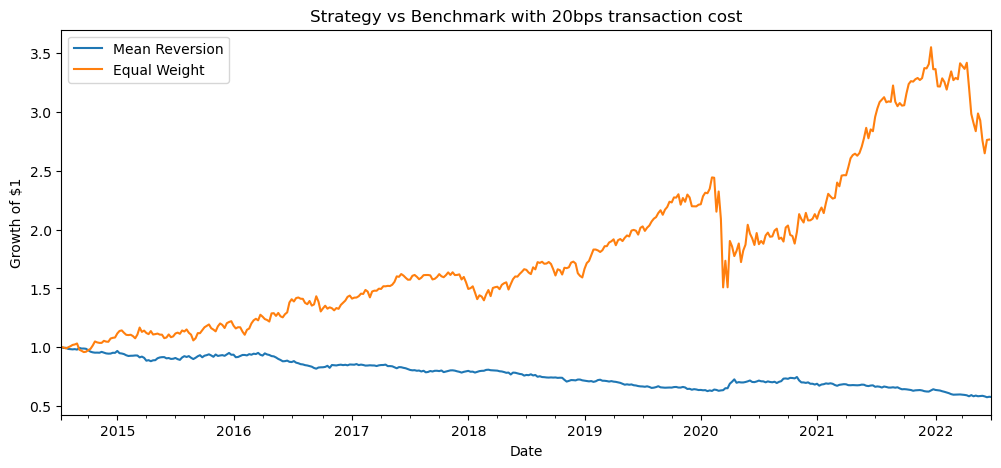

In [12]:
end = df.index.max() - pd.DateOffset(years=4)
start = end - pd.DateOffset(years=12)

cost = [5, 10, 20]

for c in cost:
    strategy = run_backtest(df, start_date=start, end_date=end, cost_bps=c)
    benchmark = run_benchmark(df, start_date=start, end_date=end)

    print("--- Strategy ---")
    print_stats(strategy["stats"])

    print("--- Benchmark ---")
    print_stats(benchmark["stats"])


    equity = strategy["equity"]
    cluster_equity = benchmark["equity"]

    plt.figure(figsize=(12, 5))
    (equity / equity.iloc[0]).plot(label="Mean Reversion")
    (cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
    plt.legend()
    plt.ylabel("Growth of $1")
    plt.title(f"Strategy vs Benchmark with {c}bps transaction cost")
    plt.show()

#### Conclusion
When the transaction cost was 5bps, the algorithm performed slightly worse but still tolerable. However, at 10 and 20 bps it was significantly underperforming the very basic equal weight buy and hold strategy. This is expected, as the current strategy as it is rebalances every single week, so the transaction costs add up. This provides a good motivation for meta-labelling, as we will train a machine learning model to selectively pick out which trades to take, which should not only boost the strategy's effectiviness, but also its cost tolerance.

### 3.5 Walk-forward selection of tau

For the backtest, we will use the following dates.

| Evaluation period | Tau-selection period |
|---|---|
| 2019 | 2016–2018 |
| 2020 | 2017–2019 |
| 2021 | 2018–2020 |
| 2022 | 2019–2021 |
| 2023 | 2020–2022 |
| 2024 | 2021–2023 |
| 2025 | 2022–2024 |
| 2026 YTD | 2023–2025 |


#### Step 1: Prepare one shared weekly dataset

I calculate weekly returns once from the already-downloaded `df`, then slice by
date. This is safer than recalculating returns separately for each year because
the first return in a new period still needs the price from the previous week.

For this experiment, I will fix the transaction cost at 10bps for simplicity, as it is very roughly the average commision rate I will experience from different brokers.

In [7]:
bps = 10
walk_forward_years = [2019,2020,2021,2022,2023,2024,2025,2026]

tau_candidates = [
    0.000,   # no threshold
    0.005,   # 0.5%
    0.010,   # 1.0%
    0.015,   # 1.5%
]

In [8]:
last_completed_week = pd.Timestamp(end_date) - pd.offsets.Week(weekday=4)

# One shared return panel for all walk-forward splits.
wf_log_returns, wf_simple_returns = prepare_weekly_data(df)
wf_log_returns = wf_log_returns.loc[:last_completed_week]
wf_simple_returns = wf_simple_returns.loc[:last_completed_week]
wf_forward_returns = wf_simple_returns.shift(-1)

# A series of dates where every stock has a known next-week return.
complete_signal_dates = wf_forward_returns.dropna(how="any").index

timeline_rows = []

for evaluation_year in walk_forward_years:
    evaluation_dates = complete_signal_dates[
        complete_signal_dates.year == evaluation_year
    ]

    tau_dates_with_gap = complete_signal_dates[
        (complete_signal_dates.year >= evaluation_year - 3)
        & (complete_signal_dates.year < evaluation_year)
    ]

    # The final historical signal week is the one-week gap.
    gap_date = tau_dates_with_gap[-1]
    tau_dates = tau_dates_with_gap[:-1]

    timeline_rows.append(
        {
            "evaluation": (
                f"{evaluation_year} YTD"
                if evaluation_year == 2026
                else str(evaluation_year)
            ),
            "tau_start": tau_dates.min().date(),
            "tau_end": tau_dates.max().date(),
            "gap_week": gap_date.date(),
            "evaluation_start": evaluation_dates.min().date(),
            "evaluation_end": evaluation_dates.max().date(),
        }
    )

# This is simply for visualisation
walk_forward_timeline = pd.DataFrame(timeline_rows)
walk_forward_timeline


,evaluation,tau_start,tau_end,gap_week,evaluation_start,evaluation_end
0,2019,2016-01-01,2018-12-21,2018-12-28,2019-01-04,2019-12-27
1,2020,2017-01-06,2019-12-20,2019-12-27,2020-01-03,2020-12-25
2,2021,2018-01-05,2020-12-18,2020-12-25,2021-01-01,2021-12-31
3,2022,2019-01-04,2021-12-24,2021-12-31,2022-01-07,2022-12-30
4,2023,2020-01-03,2022-12-23,2022-12-30,2023-01-06,2023-12-29
5,2024,2021-01-01,2023-12-22,2023-12-29,2024-01-05,2024-12-27
6,2025,2022-01-07,2024-12-20,2024-12-27,2025-01-03,2025-12-26
7,2026 YTD,2023-01-06,2025-12-19,2025-12-26,2026-01-02,2026-06-19


#### Step 2: Select tau using historical results only

For every evaluation year:

- `tau_dates` contains only the previous three years, minus the gap week.
- Create dollar position for each candidate `tau` using `build_mean_reversion_positions` function.
- We backtest the whole three years once, and then split by year to calculate Sharpe for each year.
- Select a candidate only if its Sharpe beats `tau=0` in at least two of those years.
- Among eligible candidates, the one with the highest combined three-year Sharpe is selected. A tie goes to the smaller tau.

In [9]:
tau_selection_tables = {}
selected_tau_by_year = {}
outer_year_rows = []

rolling_tau_position_parts = []
tau_zero_position_parts = []

for evaluation_year in walk_forward_years:

    # 1. Some data prep, selecting only the dates for the current evaluation year
    evaluation_dates = complete_signal_dates[
        complete_signal_dates.year == evaluation_year
    ]

    tau_dates_with_gap = complete_signal_dates[
        (complete_signal_dates.year >= evaluation_year - 3)
        & (complete_signal_dates.year < evaluation_year)
    ]
    tau_dates = tau_dates_with_gap[:-1]
    selection_years = list(range(evaluation_year - 3, evaluation_year))

    candidate_rows = []
    candidate_positions = {}

    # 2. Now we test each tau value
    for tau in tau_candidates:
        # Dollar positions for that tau
        dollar_positions = build_mean_reversion_positions(
            weekly_log_returns=wf_log_returns,
            gross_exposure=I,
            tau=tau,
        )
        # Store positions
        candidate_positions[tau] = dollar_positions

        combined_result = backtest_positions(
            target_positions=dollar_positions.loc[tau_dates],
            forward_returns=wf_forward_returns.loc[tau_dates],
            initial_capital=I,
            cost_bps=bps,
        )

        # Save results for that tau
        candidate_row = {
            "tau": tau,
            "combined_sharpe": combined_result["stats"]["sharpe"],
            "combined_return_pct": (
                combined_result["stats"]["total_return"] * 100
            ),
        }

        # Calculate sharpe for each SELECTION year (if we are trying to find tau for 2019, the for loop below will calculate the sharpe for 2016, 2017 and 2018)
        for selection_year in selection_years:
            year_dates = tau_dates[tau_dates.year == selection_year]
            year_net_returns = combined_result["net_return"].loc[year_dates]
            year_volatility = year_net_returns.std()

            year_sharpe = (
                year_net_returns.mean()
                / year_volatility
                * np.sqrt(52)
            )

            candidate_row[f"sharpe_{selection_year}"] = year_sharpe

        candidate_rows.append(candidate_row)

    # 3. Now we select the best tau for the current evaluation year, based ONLY on the previous 3 years
    candidate_table = pd.DataFrame(candidate_rows)

    # Setting up info for baseline, which is tau=0
    baseline_row = candidate_table[candidate_table["tau"] == 0.0].iloc[0]

    year_sharpe_columns = [
        f"sharpe_{selection_year}"
        for selection_year in selection_years
    ]

    candidate_table["years_beating_tau_0"] = candidate_table.apply(
        lambda row: sum(
            row[column] > baseline_row[column]
            for column in year_sharpe_columns
        ),
        axis=1,
    )

    candidate_table["eligible"] = (
        (candidate_table["tau"] > 0)
        & (candidate_table["years_beating_tau_0"] >= 2)
    )

    eligible_candidates = candidate_table[candidate_table["eligible"]]

    if eligible_candidates.empty:
        selected_tau = 0.0
    else:
        selected_tau = float(
            eligible_candidates.sort_values(
                ["combined_sharpe", "tau"],
                ascending=[False, True], # give priority to lower tau with higher sharpe
            ).iloc[0]["tau"] # only pic the tau value
        )

    # mark selected tau
    candidate_table["selected"] = np.isclose(
        candidate_table["tau"], selected_tau
    )

    tau_selection_tables[evaluation_year] = candidate_table
    selected_tau_by_year[evaluation_year] = selected_tau

    # 4. Apply selected tau to the evaluation year
    # Select correct positions
    selected_outer_positions = candidate_positions[selected_tau].loc[
        evaluation_dates
    ]
    tau_zero_outer_positions = candidate_positions[0.0].loc[evaluation_dates]

    # Save for future backtest
    rolling_tau_position_parts.append(selected_outer_positions)
    tau_zero_position_parts.append(tau_zero_outer_positions)

    # Backtest evaluation year
    outer_result = backtest_positions(
        target_positions=selected_outer_positions,
        forward_returns=wf_forward_returns.loc[evaluation_dates],
        initial_capital=I,
        cost_bps=bps,
    )

    outer_year_rows.append(
        {
            "evaluation": (
                f"{evaluation_year} YTD"
                if evaluation_year == 2026
                else str(evaluation_year)
            ),
            "selected_tau": selected_tau,
            "outer_return_pct": outer_result["stats"]["total_return"] * 100,
            "outer_sharpe": outer_result["stats"]["sharpe"],
            "outer_max_drawdown_pct": (
                outer_result["stats"]["max_drawdown"] * 100
            ),
            "outer_turnover": outer_result["stats"]["total_turnover"],
            "active_weeks": int(
                selected_outer_positions.abs().sum(axis=1).gt(0).sum()
            ),
        }
    )

tau_outer_results = pd.DataFrame(outer_year_rows)
tau_outer_results


,evaluation,selected_tau,outer_return_pct,outer_sharpe,outer_max_drawdown_pct,outer_turnover,active_weeks
0,2019,0.010,-3.902231,-0.593720,-7.700698,712688.404059,41
1,2020,0.015,26.236321,1.891104,-6.634292,732272.128679,43
2,2021,0.015,6.205838,0.819768,-6.669103,604786.055522,34
3,2022,0.015,-3.873869,-0.541812,-8.081693,616042.103616,34
4,2023,0.015,-12.078615,-1.667072,-13.194558,553665.531383,32
5,2024,0.015,10.587107,1.757669,-3.829419,694136.950167,38
6,2025,0.005,3.603801,0.551189,-4.558035,801662.524124,52
7,2026 YTD,0.010,3.339810,1.182590,-2.024783,377309.238034,22


Debug print for inspection:

In [10]:
for evaluation_year, selection_table in tau_selection_tables.items():
    print(f"\nTau selection before {evaluation_year}")
    display(selection_table)

display(tau_outer_results)



Tau selection before 2019


,tau,combined_sharpe,combined_return_pct,sharpe_2016,sharpe_2017,sharpe_2018,years_beating_tau_0,eligible,selected
0,0.000,-0.135151,-2.998003,-0.221804,0.143230,-0.260250,0,False,False
1,0.005,-0.174147,-4.125250,-0.256967,0.122747,-0.311876,0,False,False
2,0.010,-0.013284,-1.156418,0.206649,-0.030932,-0.258701,2,True,True
3,0.015,-0.510512,-12.223001,-0.459913,-1.489707,0.185408,1,False,False



Tau selection before 2020


,tau,combined_sharpe,combined_return_pct,sharpe_2017,sharpe_2018,sharpe_2019,years_beating_tau_0,eligible,selected
0,0.000,-0.340376,-5.758639,0.158283,-0.371459,-0.799266,0,False,False
1,0.005,-0.425978,-8.105181,0.136772,-0.446709,-0.908974,0,False,False
2,0.010,-0.336161,-7.244903,-0.015489,-0.392377,-0.594298,1,False,False
3,0.015,-0.643018,-12.536414,-1.473447,0.051525,-0.751190,2,True,True



Tau selection before 2021


...


Tau selection before 2025


,tau,combined_sharpe,combined_return_pct,sharpe_2022,sharpe_2023,sharpe_2024,years_beating_tau_0,eligible,selected
0,0.000,-0.142256,-3.343949,-0.973012,-1.374162,2.871407,0,False,False
1,0.005,-0.079335,-2.333367,-1.045391,-1.271735,3.007205,2,True,True
2,0.010,0.043718,0.130014,-1.097675,-1.342737,2.852908,1,False,False
3,0.015,-0.305404,-6.733327,-0.541812,-1.667072,1.737968,1,False,False



Tau selection before 2026


,tau,combined_sharpe,combined_return_pct,sharpe_2023,sharpe_2024,sharpe_2025,years_beating_tau_0,eligible,selected
0,0.000,0.444455,8.045254,-1.363347,2.798547,0.623172,0,False,False
1,0.005,0.561065,11.020097,-1.258423,2.952347,0.738094,3,True,False
2,0.010,0.719826,16.253456,-1.342737,2.837438,0.939874,3,True,True
3,0.015,0.023138,-0.172152,-1.667072,1.757669,0.517329,0,False,False


,evaluation,selected_tau,outer_return_pct,outer_sharpe,outer_max_drawdown_pct,outer_turnover,active_weeks
0,2019,0.010,-3.902231,-0.593720,-7.700698,712688.404059,41
1,2020,0.015,26.236321,1.891104,-6.634292,732272.128679,43
2,2021,0.015,6.205838,0.819768,-6.669103,604786.055522,34
3,2022,0.015,-3.873869,-0.541812,-8.081693,616042.103616,34
4,2023,0.015,-12.078615,-1.667072,-13.194558,553665.531383,32
5,2024,0.015,10.587107,1.757669,-3.829419,694136.950167,38
6,2025,0.005,3.603801,0.551189,-4.558035,801662.524124,52
7,2026 YTD,0.010,3.339810,1.182590,-2.024783,377309.238034,22


#### Step 4: Backtest unseen years with their chosen Sharpe

In the steps above we have chosen the optimal `tau` for each year 2019-2026 using the past three years of data. Below, we run a backtest, where each of the years 2019-2026 is backtested using its selected `tau` value. The results are plotted accordingly.


,strategy,return_pct,sharpe,max_drawdown_pct,turnover
0,Tau = 0,13.086174,0.264241,-20.764482,5.571020e+06
1,Annual rolling tau,28.629652,0.462830,-18.667774,5.115293e+06


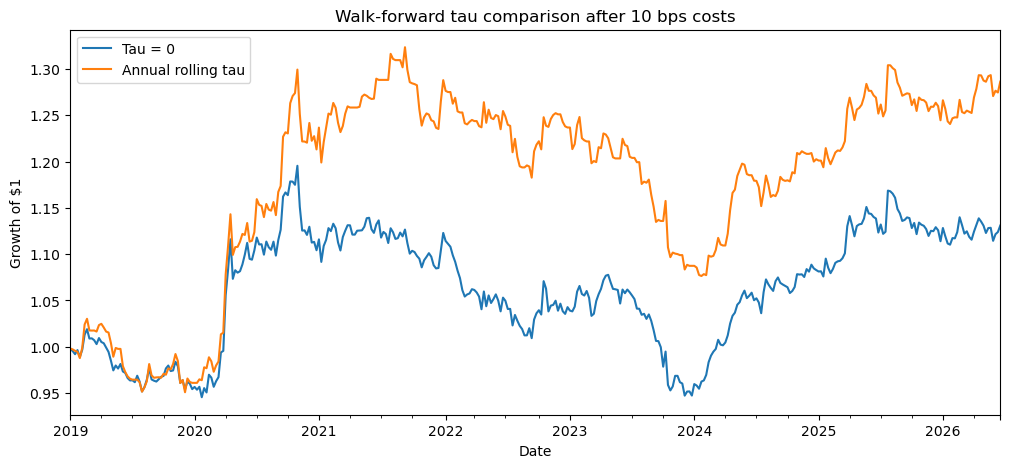

All tau walk-forward checks passed.
TAU_BY_YEAR = {
    '2019': 0.01,
    '2020': 0.015,
    '2021': 0.015,
    '2022': 0.015,
    '2023': 0.015,
    '2024': 0.015,
    '2025': 0.005,
    '2026 YTD': 0.01,
}


In [11]:
rolling_tau_positions = pd.concat(rolling_tau_position_parts).sort_index()
tau_zero_positions = pd.concat(tau_zero_position_parts).sort_index()
outer_dates = rolling_tau_positions.index

rolling_tau_result = backtest_positions(
    target_positions=rolling_tau_positions,
    forward_returns=wf_forward_returns.loc[outer_dates],
    initial_capital=I,
    cost_bps=bps,
)

tau_zero_result = backtest_positions(
    target_positions=tau_zero_positions,
    forward_returns=wf_forward_returns.loc[outer_dates],
    initial_capital=I,
    cost_bps=bps,
)

walk_forward_tau_comparison = pd.DataFrame(
    [
        {
            "strategy": "Tau = 0",
            "return_pct": tau_zero_result["stats"]["total_return"] * 100,
            "sharpe": tau_zero_result["stats"]["sharpe"],
            "max_drawdown_pct": (
                tau_zero_result["stats"]["max_drawdown"] * 100
            ),
            "turnover": tau_zero_result["stats"]["total_turnover"],
        },
        {
            "strategy": "Annual rolling tau",
            "return_pct": rolling_tau_result["stats"]["total_return"] * 100,
            "sharpe": rolling_tau_result["stats"]["sharpe"],
            "max_drawdown_pct": (
                rolling_tau_result["stats"]["max_drawdown"] * 100
            ),
            "turnover": rolling_tau_result["stats"]["total_turnover"],
        },
    ]
)

display(walk_forward_tau_comparison)

plt.figure(figsize=(12, 5))
(tau_zero_result["equity"] / I).plot(label="Tau = 0")
(rolling_tau_result["equity"] / I).plot(label="Annual rolling tau")
plt.title("Walk-forward tau comparison after 10 bps costs")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

for evaluation_year in walk_forward_years:
    evaluation_dates = complete_signal_dates[
        complete_signal_dates.year == evaluation_year
    ]
    historical_dates = complete_signal_dates[
        (complete_signal_dates.year >= evaluation_year - 3)
        & (complete_signal_dates.year < evaluation_year)
    ]
    gap_date = historical_dates[-1]
    tau_dates = historical_dates[:-1]

    assert tau_dates.max() < gap_date
    assert gap_date < evaluation_dates.min()

assert complete_signal_dates.max() < last_completed_week

# Visualise positions for tau=0
original_tau_zero_positions = run_backtest(
    prices=df,
    end_date=last_completed_week,
    I=I,
    cost_bps=0,
    tau=0.0,
)["dollar_positions"]

rebuilt_tau_zero_positions = build_mean_reversion_positions(
    weekly_log_returns=wf_log_returns,
    gross_exposure=I,
    tau=0.0,
)

# Safety check to ensure original and rebuilt positions are the same
pd.testing.assert_frame_equal(
    original_tau_zero_positions,
    rebuilt_tau_zero_positions,
)

# Check gross exposure == I and net exposure == 0
for positions_name, positions_to_check in {
    "tau=0": tau_zero_positions,
    "rolling tau": rolling_tau_positions,
}.items():
    gross_exposure = positions_to_check.abs().sum(axis=1)
    net_exposure = positions_to_check.sum(axis=1)

    assert np.all(
        np.isclose(gross_exposure, 0)
        | np.isclose(gross_exposure, I)
    ), positions_name
    assert np.allclose(net_exposure, 0, atol=1e-8), positions_name

print("All tau walk-forward checks passed.")

# Print out a Python dictionary suitable for assignment, for copy-pasting
print("TAU_BY_YEAR = {")
for _, row in tau_outer_results.iterrows():
    print(f"    '{row['evaluation']}': {row['selected_tau']},")
print("}")


#### Conclusion
From the above, it is clear that the algorithm performs better when we select an appropriate tau for each year. While the tau value does not always guarantee optimal performance, when combined throughout multiple years, the results are better than simply accepting all trades.